# Pilier État — du typage CarDD au binaire sur photos d'annonce

Ce carnet consigne la bascule du pilier État, et surtout **ce qui l'a rendue nécessaire**.

Point de départ : le modèle CarDD de la phase 1 atteint **macro-F1 = 0,815** sur son propre jeu de
test — des gros plans où le dégât occupe 30 à 80 % du cadre. Question posée ensuite : tient-il sur
une photo d'annonce leboncoin ? Quatre mesures y répondent, et chacune ferme une piste.

| # | question | réponse | où |
|---|---|---|---|
| 1 | l'état déclaré par le vendeur décrit-il la photo ? | **oui à 98 % côté intact, non à 40 % côté abîmé** | §2 |
| 2 | le modèle CarDD sait-il ordonner des photos d'annonce ? | **non — aire ROC 0,509**, soit le hasard | §3 |
| 3 | la tâche s'apprend-elle sur ce domaine ? | **oui — précision moyenne 0,615 contre un plancher de 0,223** | §4 |
| 4 | manque-t-il des données ? | **non — courbe d'apprentissage plate** | §4 |
| 5 | qu'est-ce qui bloque, alors ? | **l'échelle — résolution et détourage font gagner +0,074** | §5 |

Les expériences longues sont dans `dl/src/experiences_binaire.py` et se rejouent par
`python dl/src/experiences_binaire.py {transfert|pilote|leviers}`. Ce carnet relit leurs résultats
et refait sur place les analyses légères.

In [1]:
import sys
sys.path.insert(0, "../../src")

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

import experiences_binaire as xp

ANNOT = xp.ANNOT
df = xp.charger_annotations(jugeables_seulement=False)
print(f"{len(df)} photos annotées à l'aveugle")

648 photos annotées à l'aveugle


## 1. Le protocole d'annotation

800 photos tirées au hasard dans les 4 dossiers d'état déclaré les moins ambigus (`undamaged`,
`excellent_condition`, `damaged`, `not_drivable`), **une photo par annonce** — donc 800 voitures
différentes, et aucune fuite possible entre découpages.

Trois précautions, toutes destinées à empêcher l'étiquette déclarée d'influencer le jugement :

1. **copie sous nom neutre** (`0001.jpg`) : le chemin ne révèle plus le dossier d'origine ;
2. **ordre mélangé** : pas d'effet de série ;
3. **filtre automatique en amont** (`detect.py`) : les photos sans véhicule visible (habitacle,
   compteur, carte grise) sont écartées avant l'annotation — et le détecteur ne voit jamais
   l'étiquette, sinon il fabriquerait le raccourci qu'on cherche à éviter.

Le filtre a gardé 648 photos sur 800, avec des taux de rejet quasi identiques entre les quatre
dossiers (16 % à 21 %) : il nettoie **sans déformer** la composition du jeu. C'est vérifié
ci-dessous, pas supposé.

In [2]:
man = pd.read_csv(ANNOT / "manifeste.csv", dtype={"id": str})
rejet = pd.crosstab(man.etat_declare, man.garde, normalize="index").round(3)
rejet.columns = ["écartée par le filtre", "gardée"]
display(rejet)
print(f"gardées : {int(man.garde.sum())} / {len(man)}")

,écartée par le filtre,gardée
etat_declare,,
damaged,0.165,0.835
excellent_condition,0.200,0.800
not_drivable,0.180,0.820
undamaged,0.215,0.785


gardées : 648 / 800


## 2. Ce que vaut l'état déclaré par le vendeur

Verdicts humains croisés avec le dossier d'origine — que l'annotateur n'a jamais vu.

In [3]:
print(df.verdict.value_counts().to_string(), "\n")
display(pd.crosstab(df.etat_declare, df.verdict))

jug = df[df.verdict.isin(["intact", "abime"])]
accord = (jug.verdict == jug.classe_declaree).mean()
print(f"photos jugeables : {len(jug)} | accord avec l'état déclaré : {accord*100:.1f} %")
display(pd.crosstab(jug.classe_declaree, jug.verdict, normalize="index").round(3))

verdict
intact    366
jeter     177
abime     105 



verdict,abime,intact,jeter
etat_declare,,,
damaged,66,55,46
excellent_condition,2,112,46
not_drivable,36,99,29
undamaged,1,100,56


photos jugeables : 471 | accord avec l'état déclaré : 66.7 %


verdict,abime,intact
classe_declaree,,
abime,0.398,0.602
intact,0.014,0.986


**Le bruit est totalement asymétrique**, et sa cause est structurelle.

| dossier déclaré | jugé « abîmé » | jugé « intact » | fiabilité |
|---|---|---|---|
| `undamaged` | 1 | 100 | **99 %** |
| `excellent_condition` | 2 | 112 | **98 %** |
| `damaged` | 66 | 55 | 55 % |
| `not_drivable` | 36 | 99 | **27 %** |

L'état déclaré porte sur **le véhicule**, la photo montre **une vue**. Une annonce `damaged`
contient trois ou quatre photos dont une seule cadre l'aile froissée ; les autres montrent l'avant
intact, le profil, les jantes. La déclaration est vraie au niveau de l'annonce et fausse au niveau
de trois photos sur quatre.

`not_drivable` est le cas extrême : 73 % de photos sans dégât visible. « Non roulant » désigne
souvent un moteur ou une boîte hors service — sur une carrosserie impeccable. L'étiquette est
juste, elle ne parle simplement pas de ce que le modèle regarde.

> **Conséquence.** Les **négatifs déclarés sont exploitables à grande échelle** (5 355 photos,
> ~98 % justes). Les **positifs déclarés ne le sont pas** : entraîner dessus apprendrait au réseau
> que des voitures visiblement intactes sont abîmées, ce qui détruirait sa précision. C'est cette
> mesure de vingt minutes qui l'établit — sans elle, on entraînait sur 60 % d'étiquettes fausses.

## 3. Le modèle CarDD ne transfère pas

On lui donne les 471 photos jugeables et on mesure l'**aire sous la courbe ROC** contre le verdict
humain. Cette mesure ne dépend d'aucun seuil : elle dit seulement si le modèle sait *ordonner* les
photos. C'est ce qui la rend décisive — si elle vaut 0,5, aucune calibration ne pourra rien sauver.

Rejouable par `python dl/src/experiences_binaire.py transfert`.

In [4]:
transfert = pd.read_csv(ANNOT / "transfert_cardd.csv")
display(transfert)

pc = pd.read_csv(ANNOT / "probas_cardd.csv")
print("probabilité moyenne par groupe :")
display(pc.groupby("verdict").mean().round(3))

,signal,aire ROC
0,max des 6 probabilités,0.509
1,dent,0.460
2,scratch,0.544
3,crack,0.510
4,glass shatter,0.504
5,lamp broken,0.447
6,tire flat,0.510


probabilité moyenne par groupe :


,dent,scratch,crack,glass shatter,lamp broken,tire flat
verdict,,,,,,
abime,0.767,0.396,0.417,0.451,0.325,0.081
intact,0.813,0.335,0.386,0.435,0.357,0.055


**0,509 : le hasard.** Deux classes passent même sous 0,5 (`dent` 0,460, `lamp broken` 0,447), et
`dent` est en moyenne **plus élevée sur les voitures intactes** que sur les abîmées. Le modèle ne
répond pas au bruit : il répond à autre chose — forme du véhicule, angle, couleur — sans rapport
avec la présence d'un dégât.

Le 0,815 de CarDD n'était pas faux, il était **hors sujet**. Excellent pour typer un dégât sur un
gros plan de dégât ; sans aucune prise sur une photo d'annonce. C'est la définition du décalage de
domaine, ici chiffrée.

Trois conséquences immédiates :
- la piste « régler les seuils du modèle CarDD » est close, définitivement ;
- la piste « trier les photos à annoter avec CarDD pour tomber plus souvent sur des dégâts » aussi :
  à 0,509, ce tri vaudrait un tirage au sort ;
- un sondage antérieur sur 13 photos avait suggéré le contraire. 13 photos regardées à l'œil ne
  décident pas ; 471 en validation croisée, oui.

## 4. La tâche s'apprend — et ce ne sont pas les données qui manquent

Binaire ResNet18, une sortie, perte pondérée (déséquilibre 3,5 pour 1), validation croisée en
5 blocs : chaque photo est prédite par un modèle qui ne l'a jamais vue.

**Deux métriques, et la seconde est celle qui compte.** L'aire ROC flatte en déséquilibre, car les
366 négatifs dominent le calcul. La **précision moyenne** (aire sous la courbe précision/rappel) ne
regarde que la classe rare : son plancher n'est pas 0,5 mais la prévalence, soit 105/471 = **0,223**.

Rejouable par `python dl/src/experiences_binaire.py pilote`.

,modèle,aire ROC,précision moyenne,prévalence (plancher),meilleur F1,précision à ce seuil,rappel à ce seuil,seuil,durée (s)
0,init imagenet,0.818,0.615,0.223,0.589,0.598,0.581,0.404,90.0
1,init cardd,0.782,0.578,0.223,0.551,0.456,0.695,0.316,88.0
2,imagenet — 25 % des données,0.802,0.584,0.223,0.595,0.564,0.629,0.512,NaN
3,imagenet — 50 % des données,0.816,0.617,0.223,0.591,0.514,0.695,0.419,NaN
4,imagenet — 75 % des données,0.810,0.627,0.223,0.597,0.663,0.543,0.650,NaN


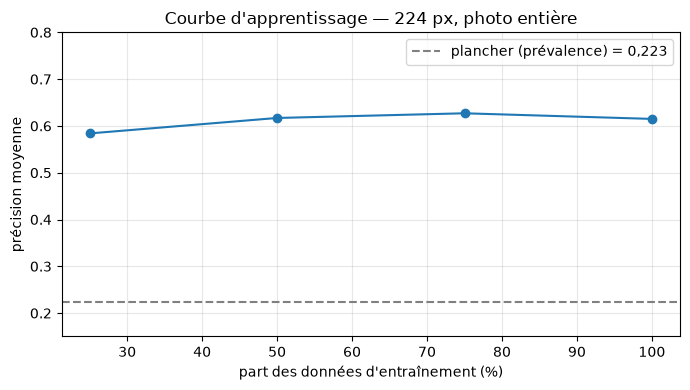

In [5]:
pilote = pd.read_csv(ANNOT / "pilote_resultats.csv")
display(pilote)

courbe = pilote[pilote["modèle"].str.contains("%")].copy()
courbe["part"] = [25, 50, 75]
complet = pilote.loc[pilote["modèle"] == "init imagenet", "précision moyenne"].iloc[0]

plt.figure(figsize=(7, 4))
plt.plot(list(courbe.part) + [100], list(courbe["précision moyenne"]) + [complet], marker="o")
plt.axhline(0.223, ls="--", color="gray", label="plancher (prévalence) = 0,223")
plt.ylim(0.15, 0.8); plt.grid(alpha=.3); plt.legend()
plt.xlabel("part des données d'entraînement (%)"); plt.ylabel("précision moyenne")
plt.title("Courbe d'apprentissage — 224 px, photo entière")
plt.tight_layout(); plt.show()

**La tâche s'apprend** : 0,615 contre un plancher de 0,223, soit 2,8 fois le hasard, là où CarDD
plafonnait au tirage au sort. Le domaine annonce est apprenable, à partir de 471 photos annotées
en une vingtaine de minutes.

**Le tronc CarDD n'apporte rien** (0,578 contre 0,615 pour ImageNet). L'écart reste dans le bruit,
donc on ne dira pas qu'il nuit — mais ses filtres, spécialisés sur des textures en gros plan, ne
valent pas un point de départ généraliste face à une voiture entière photographiée à trois mètres.

**La courbe est plate** : 0,584 à 25 % des données, 0,615 à 100 %. Les blocs varient de 0,65 à 0,92
en aire ROC, soit une incertitude d'environ ±0,05 : les quatre valeurs sont indistinguables. À 25 %,
le modèle voit ~94 photos dont ~21 abîmées et fait déjà aussi bien qu'avec 377.

> **C'est le résultat le plus actionnable du pilote** : il économise une session d'annotation
> supplémentaire. Le facteur limitant n'est pas la quantité de données — il est ailleurs.

## 5. Ce qui bloque : l'échelle

Deux leviers qui attaquent la même hypothèse par des côtés opposés — plus de pixels sur l'image
entière, ou autant de pixels concentrés sur la carrosserie. Chacun isolé, puis combinés, sur les
mêmes 471 photos et le même découpage.

Rejouable par `python dl/src/experiences_binaire.py leviers`.

In [6]:
leviers = pd.read_csv(ANNOT / "leviers_resultats.csv")
display(leviers)

ref = leviers.loc[leviers["modèle"] == "224 px, photo entière", "précision moyenne"].iloc[0]
gains = leviers.assign(**{"gain vs référence": (leviers["précision moyenne"] - ref).round(3)})
display(gains[["modèle", "précision moyenne", "gain vs référence", "durée (s)"]])

,modèle,aire ROC,précision moyenne,prévalence (plancher),meilleur F1,précision à ce seuil,rappel à ce seuil,seuil,durée (s)
0,"224 px, photo entière",0.818,0.615,0.223,0.589,0.598,0.581,0.404,94
1,"384 px, photo entière",0.844,0.672,0.223,0.658,0.617,0.705,0.304,420
2,"224 px, détourée",0.831,0.657,0.223,0.626,0.615,0.638,0.431,90
3,"384 px, détourée",0.855,0.689,0.223,0.630,0.613,0.648,0.453,309


,modèle,précision moyenne,gain vs référence,durée (s)
0,"224 px, photo entière",0.615,0.000,94
1,"384 px, photo entière",0.672,0.057,420
2,"224 px, détourée",0.657,0.042,90
3,"384 px, détourée",0.689,0.074,309


| configuration | aire ROC | précision moyenne | gain | durée |
|---|---|---|---|---|
| plancher (hasard) | 0,500 | 0,223 | — | — |
| 224 px, photo entière | 0,818 | 0,615 | référence | 94 s |
| 224 px, détourée | 0,831 | 0,657 | +0,042 | 90 s |
| 384 px, photo entière | 0,844 | 0,672 | +0,057 | 420 s |
| **384 px, détourée** | **0,855** | **0,689** | **+0,074** | 309 s |

**Prudence sur la lecture.** Pris isolément, chaque gain est à la limite du bruit (±0,05). Ce qui
rend la conclusion solide, c'est la **cohérence du motif** : deux manipulations indépendantes vont
dans le même sens, et leur combinaison donne approximativement la somme des deux. Le bruit ne
produit pas cet ordre.

Détail économique utile : **384 px sur détourage (309 s) est plus rapide que 384 px sur photo
entière (420 s)**, les images recadrées étant plus petites à décoder. Le levier le plus efficace est
aussi l'un des moins chers.

**Où en est le produit.** Au meilleur seuil : précision 0,61, rappel 0,65. Sur 10 alertes « voiture
abîmée », environ 4 fausses ; sur 10 dégâts réels, environ 6,5 détectés. C'est un signal d'aide à la
décision défendable, pas un verdict — cohérent avec le positionnement du projet, avec de la marge
devant.

## Limites — à rappeler à chaque citation de ces chiffres

- **Vérité terrain = un seul annotateur, non expert.** Aucun accord inter-annotateurs n'a été
  mesuré. Un dégât discret jugé « intact » par erreur devient une étiquette fausse, et le modèle en
  hérite.
- **471 photos, dont 105 abîmées.** L'incertitude sur la précision moyenne est d'environ ±0,05.
  Tout écart inférieur n'est pas interprétable, et ce carnet s'y tient.
- **Le critère « abîmé » est celui de l'annotateur** : dégât de carrosserie visible sur *cette*
  photo. Ni l'usure normale, ni la saleté, ni les dégâts mécaniques ou d'intérieur.
- **Photos d'un seul segment** : annonces de particuliers, collectées en juillet 2026. Rien ne
  garantit la tenue sur les annonces professionnelles ni sur d'autres plateformes.
- **Les 177 photos « à jeter » (27 %) sont exclues** de toutes les mesures. En production, un
  quart des photos ne seront donc pas notables — le tri des vues est un prérequis, pas une option.
- **RGPD** : ces photos proviennent d'annonces en ligne et peuvent porter plaques et visages. Usage
  interne de recherche, contenu exclu de `git`, jamais rediffusé. Les copies d'annotation sont
  dérivées des originaux et suivent le même régime.